In [56]:
import sys
#%load_ext autoreload
#%autoreload 2

# for data collection
from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD_lab9
import time

# for plotting
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

LOG.propagate = False

In [57]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-04-13 19:04:25,324 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:b4:24:2b:64
2026-04-13 19:04:25,334 | INFO     |: Scanning for device with address: c0:81:b4:24:2b:64, service UUID: 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-04-13 19:04:35,412 | INFO     |: Found 1 device(s) advertising service 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-04-13 19:04:35,420 | INFO     |: Selecting device: 38645F53-E5BF-2155-7DF0-DBDE5B0B8B54 (name: Artemis BLE)
2026-04-13 19:04:36,930 | INFO     |: Connected to c0:81:b4:24:2b:64


In [58]:
# debugging data
T_arr = []
Yaw_arr = []
ToF_distance2_arr = []

In [59]:
def mapping_data_notif_handler(uuid, byte_array):
    try:
        # get data from Artemis through ble
        s = ble.bytearray_to_string(byte_array)
        
        # split string (e.g. "T:1234|Y:45|D:100") into key-value pairs
        s_split = dict(item.split(":") for item in s.split("|"))
    
        # append values to arrays for plotting
        T_arr.append(int(s_split["T"]))
        Yaw_arr.append(float(s_split["Y"]))
        ToF_distance2_arr.append(int(s_split["D"]))
    except Exception as e:
        print(f"Handler error: {e} | raw string: {s}")

In [60]:
ble.start_notify(ble.uuid['RX_STRING'], mapping_data_notif_handler)

In [61]:
# clear old data
T_arr.clear()
Yaw_arr.clear()
ToF_distance2_arr.clear()

# to avoid accumulated= drift between upload, reset yaw first
ble.send_command(CMD_lab9.RESET_YAW, "")
print("Reset Yaw to 0°")
# start orientation PID controller (motors start)
ble.send_command(CMD_lab9.START_MAPPING_360_ROTATION, "")
print("Mapping start!")
# wait for robot to reach target angle
time.sleep(3.5) 
# set new target angle (increase in incrementation of 25°, approximately 14 readinds)
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "25.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "50.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "75.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "100.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "125.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "150.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "175.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "200.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "225.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "250.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "275.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "300.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "325.0")
time.sleep(3.5) 
ble.send_command(CMD_lab9.SET_ORIENTATION_SETPOINT, "350.0")
time.sleep(3.5) 
# stop PID controller (motors stop)
ble.send_command(CMD_lab9.STOP_MAPPING_360_ROTATION, "")
print("Orientation PID stop!")
# make sure the motors have completely stopped
time.sleep(3.5) 

Reset Yaw to 0°
Mapping start!
Orientation PID stop!


In [62]:
# Artemis start BLE send data loop
ble.send_command(CMD_lab9.SEND_MAPPING_DATA, "")
print("Requesting data...")
time.sleep(10)
print(f"Received {len(T_arr)} data points")

Requesting data...
Received 0 data points


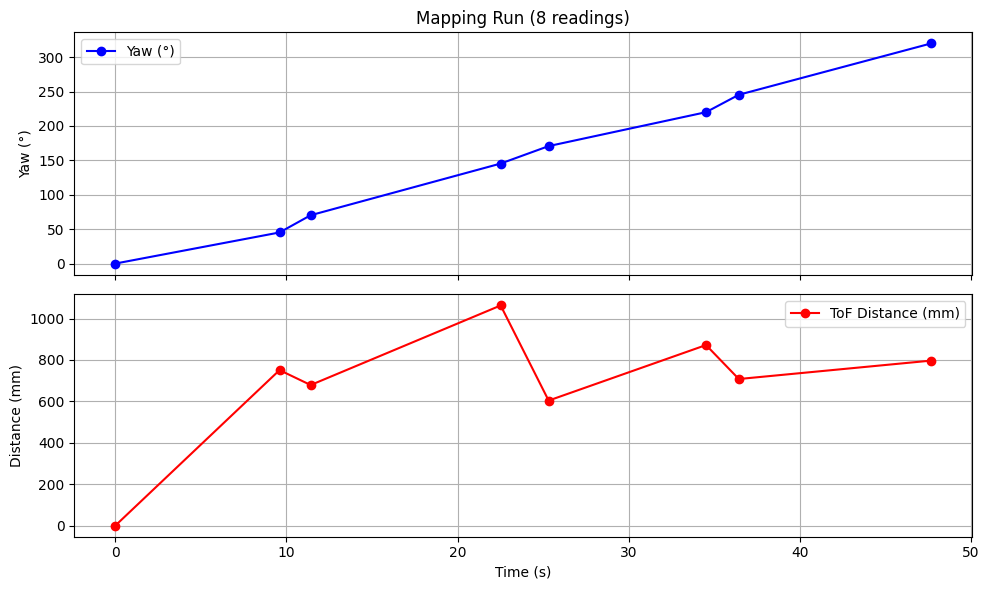

In [63]:
# plot
if len(T_arr) == 0:
    print("No data received!")
else:
    T = (np.array(T_arr) - T_arr[0]) / 1000.0
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    ax1.plot(T, Yaw_arr, 'bo-', label='Yaw (°)')
    ax1.set_ylabel('Yaw (°)'); ax1.grid(True); ax1.legend()
    ax1.set_title(f'Mapping Run ({len(T)} readings)')
    
    ax2.plot(T, ToF_distance2_arr, 'ro-', label='ToF Distance (mm)')
    ax2.set_ylabel('Distance (mm)'); ax2.set_xlabel('Time (s)')
    ax2.grid(True); ax2.legend()
    
    plt.tight_layout()
    plt.show()

In [15]:
ble.send_command(CMD_lab9.RESET_YAW, "")
print("Reset Yaw to 0°")

Reset Yaw to 0°


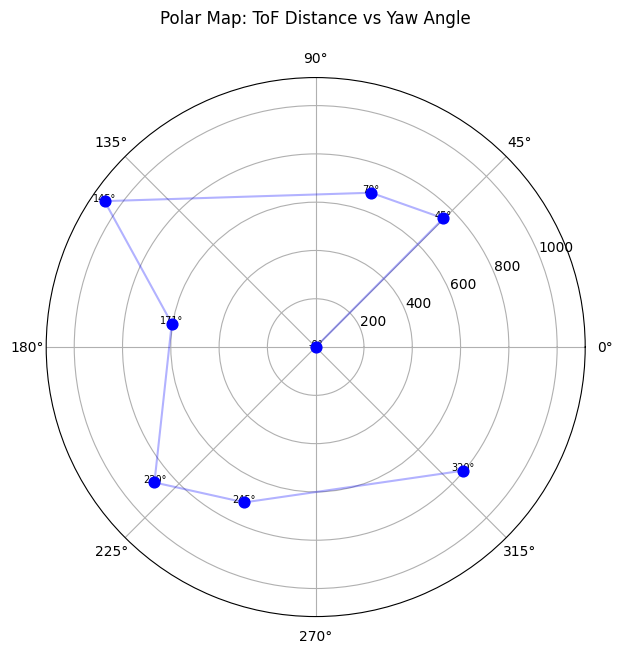

In [64]:
# polar plot
yaw_rad = np.deg2rad(np.array(Yaw_arr))
dist    = np.array(ToF_distance2_arr)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))
ax.scatter(yaw_rad, dist, c='blue', s=60, zorder=5)
ax.plot(yaw_rad, dist, 'b-', alpha=0.3)
for i, (a, d) in enumerate(zip(yaw_rad, dist)):
    ax.annotate(f'{np.degrees(a):.0f}°', (a, d), fontsize=7, ha='center')
ax.set_title("Polar Map: ToF Distance vs Yaw Angle", pad=20)
plt.show()